Extended Data Figure 3c — clinical ADT heatmap


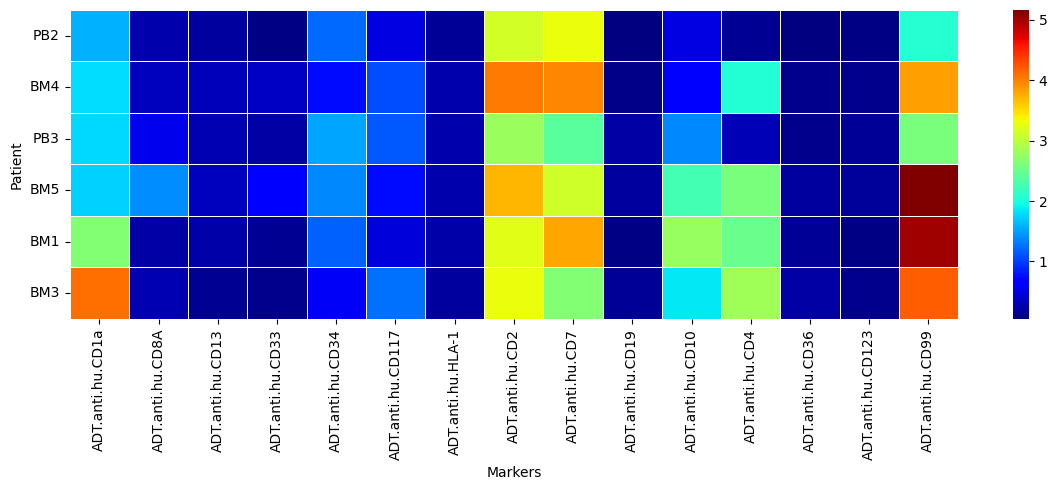

In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import muon as mu
from pathlib import Path

DATA = Path("PATH_TO_DATA")
base_path = DATA / "New_Analysis/TotalVI/New"
samples = ["BM1", "BM3", "BM4", "BM5", "PB2", "PB3"]

mdata_dict = {}
for s in samples:
    hv = base_path / s / "HV" / "DE" / f"TotalVI_{s}_TEAseq_CLEAN_HV.h5mu"
    tf = base_path / s / "HV" / "DE" / "TF" / f"TotalVI_{s}_TEAseq_CLEAN_HV_TF.h5mu"
    mdata_dict[s] = mu.read(hv if hv.exists() else tf)

fixed_marker_order = [
    "ADT.anti.hu.CD1a",
    "ADT.anti.hu.CD8A",
    "ADT.anti.hu.CD13",
    "ADT.anti.hu.CD33",
    "ADT.anti.hu.CD34",
    "ADT.anti.hu.CD117",
    "ADT.anti.hu.HLA-1",
    "ADT.anti.hu.CD2",
    "ADT.anti.hu.CD7",
    "ADT.anti.hu.CD19",
    "ADT.anti.hu.CD10",
    "ADT.anti.hu.CD4",
    "ADT.anti.hu.CD36",
    "ADT.anti.hu.CD123",
    "ADT.anti.hu.CD99",
]
patient_order = ["PB2", "BM4", "PB3", "BM5", "BM1", "BM3"]

records = []
for sample in mdata_dict:
    prot = mdata_dict[sample].mod["protein"]
    X = prot.layers["denoised_protein"]
    if sp.issparse(X):
        X = X.toarray()
    var_names = list(prot.var_names)
    for marker in fixed_marker_order:
        if marker not in var_names:
            continue
        idx = var_names.index(marker)
        records.append({
            "patient": sample,
            "marker": marker,
            "expr": X[:, idx].mean(),
        })

expr_df = pd.DataFrame(records).pivot(index="patient", columns="marker", values="expr")
expr_df = expr_df.reindex(columns=fixed_marker_order)
expr_df = expr_df.reindex(patient_order)
expr_df = np.log1p(expr_df)

plt.figure(figsize=(12, 5))
sns.heatmap(expr_df, cmap="jet", linewidths=0.5, cbar=True)
plt.xlabel("Markers")
plt.ylabel("Patient")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
